In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import muon as mu
import anndata as ad
import matplotlib.pyplot as plt
import squidpy as sq
from liana.method._pipe_utils._common import _get_props
from liana.method.sp._utils import _add_complexes_to_var
from liana._logging import _logg
from liana.method._pipe_utils import prep_check_adata, assert_covered
from scipy.sparse import csr_matrix
from pathlib import Path
from plotnine import scale_y_continuous
from plotnine import geom_vline, annotate


/home/alsayah/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
/home/alsayah/.local/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/home/alsayah/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


## Load data

In [2]:
merfish_path = Path("/g/stegle/aalsayah/repos/data/merfish")

In [3]:
adata_main = sc.read(merfish_path / "mouse_brain/WB_MERFISH_animal2_coronal.h5ad")

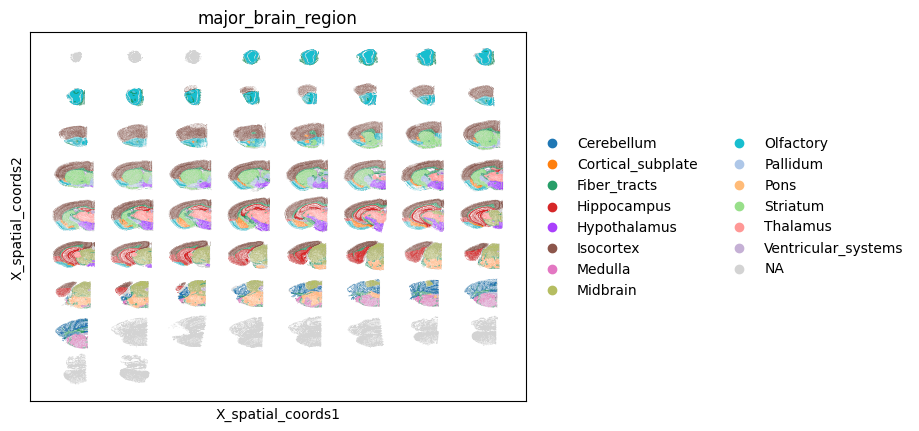

In [4]:
sc.pl.embedding(adata_main, basis="X_spatial_coords", color="major_brain_region")

In [5]:
adata = adata_main[adata_main.obs["brain_section_label"] == "C57BL6J-2.034"]

## Basic QC

In [6]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

/home/alsayah/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

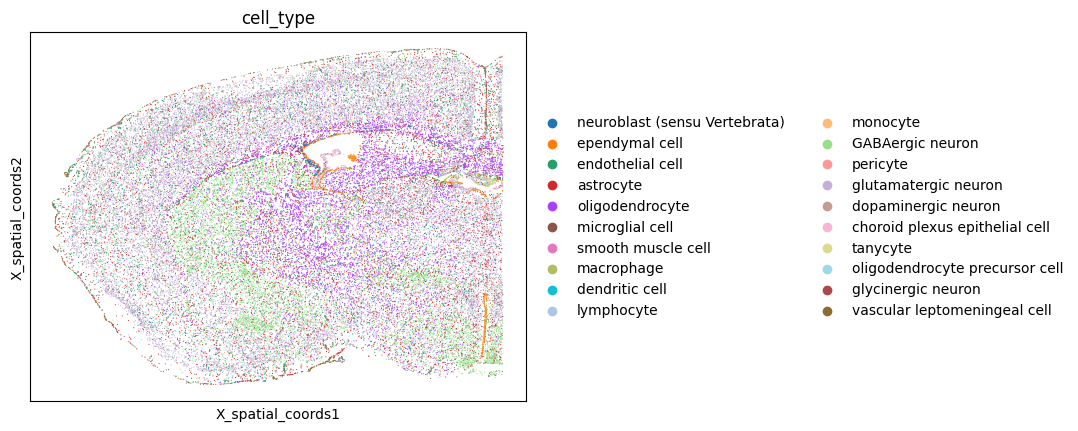

In [8]:
sc.pl.embedding(adata, basis="X_spatial_coords", color="cell_type")

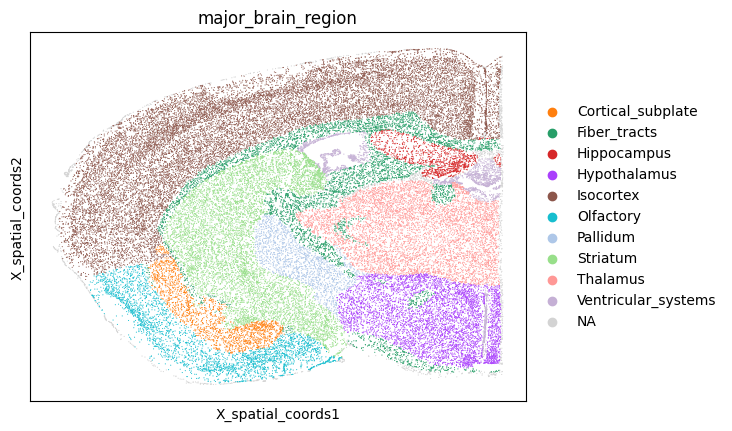

In [9]:
sc.pl.embedding(adata, basis="X_spatial_coords", color="major_brain_region")

## Calculate spatial connectivity matrix Wij

## Choose the right bandwith

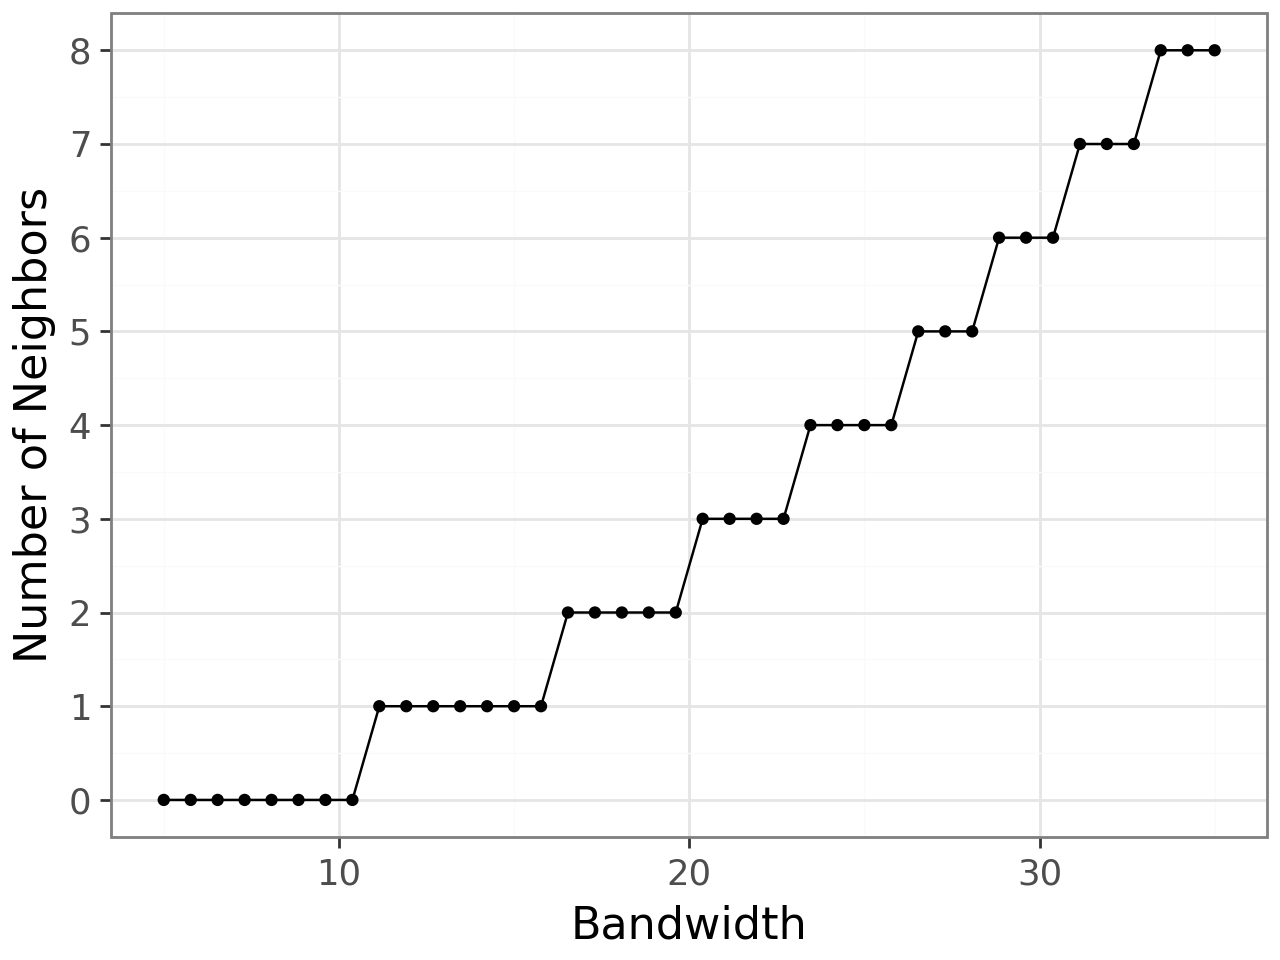

In [10]:
# around the sweet spot you explored
plot, df = li.ut.query_bandwidth(
    coordinates=adata.obsm["X_spatial_coords"],
    start=5,         
    end=35,           
    interval_n=40    
)
plot + scale_y_continuous(breaks=range(int(df.neighbours.min()), 
                                       int(df.neighbours.max())+1))

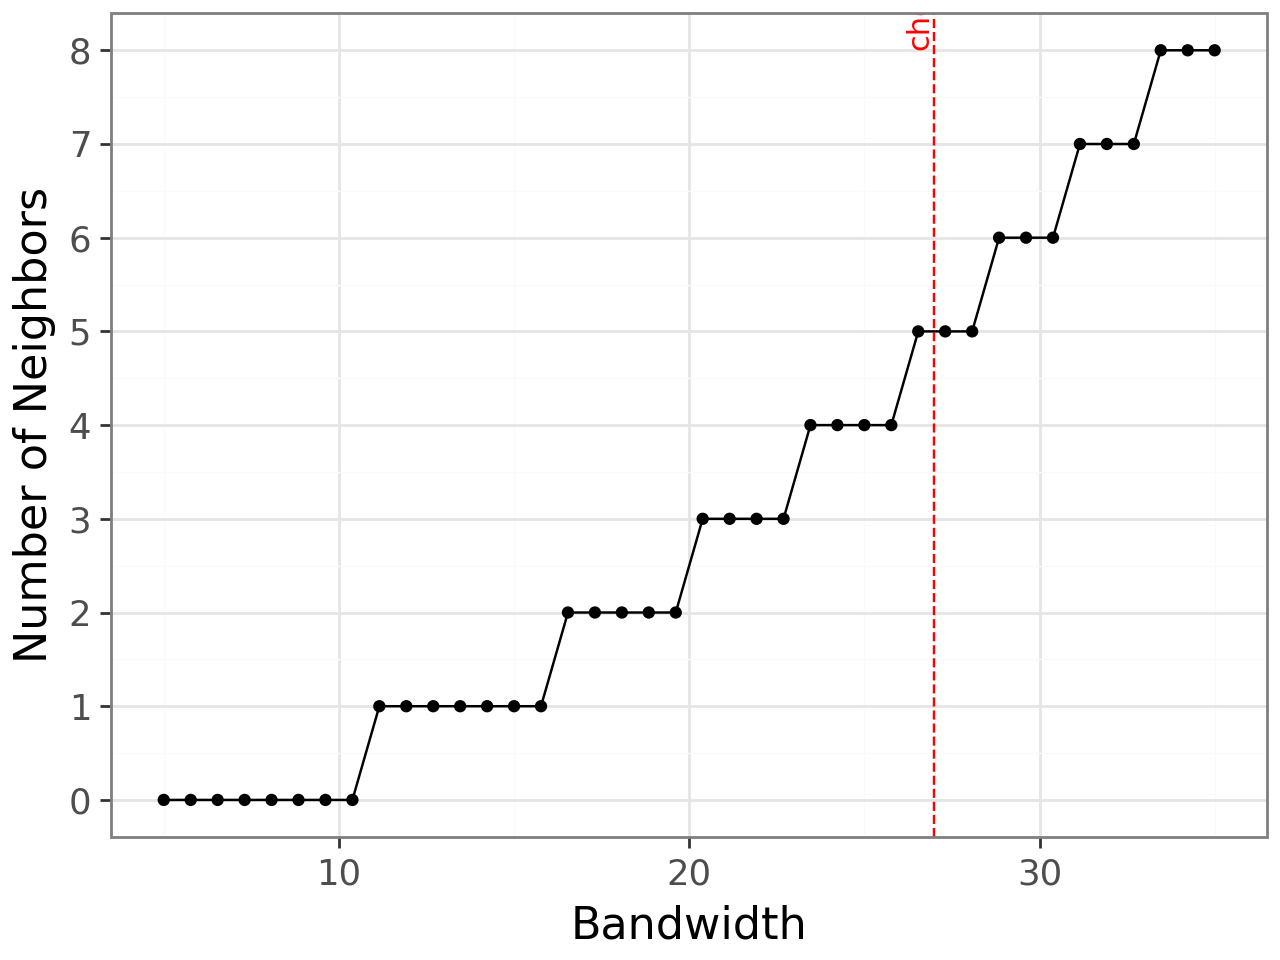

In [11]:
chosen = 27
plot + geom_vline(xintercept=chosen, linetype="dashed", color="red") + \
       annotate("text", x=chosen, y=df.neighbours.max(), 
                label=f"chosen={chosen}µm",
                angle=90, va="bottom", ha="right", color="red") + \
       scale_y_continuous(breaks=range(int(df.neighbours.min()), 
                                       int(df.neighbours.max())+1))

In [12]:
li.ut.spatial_neighbors(adata=adata, bandwidth=27, spatial_key="X_spatial_coords")

## Visualize proximity

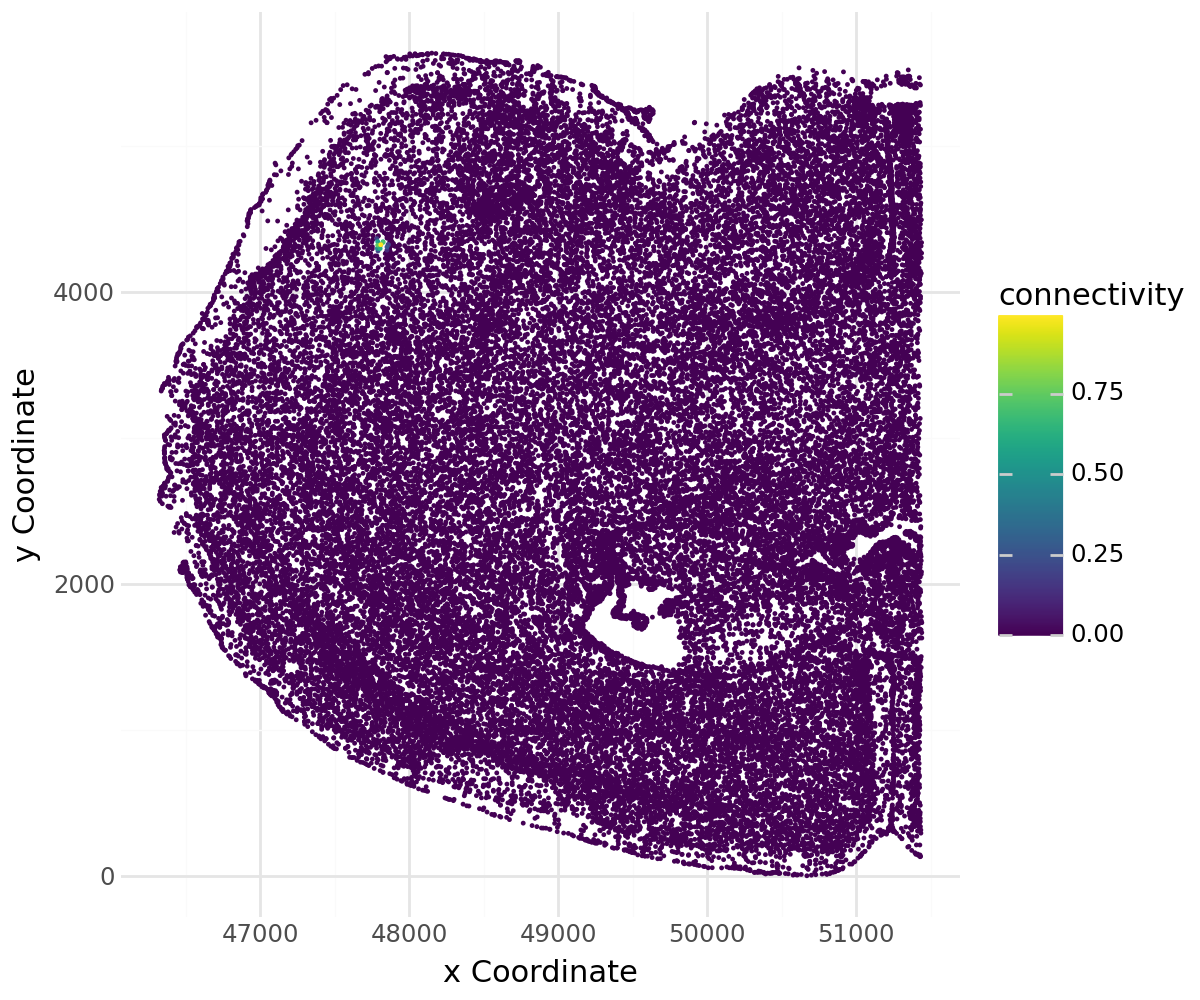

In [13]:
li.pl.connectivity(adata, idx=7000, size=0.01, figure_size=(6, 5), spatial_key="X_spatial_coords")

## Find spatially variable genes (SVGs) using Morans'I

In [14]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, n_jobs = 10,
                       show_progress_bar=True)
adata.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
ENSMUSG00000070570,0.641460,0.000000,0.000003,0.000000
ENSMUSG00000027833,0.466922,0.000000,0.000003,0.000000
ENSMUSG00000047507,0.462926,0.000000,0.000003,0.000000
ENSMUSG00000003657,0.451540,0.000000,0.000003,0.000000
ENSMUSG00000038255,0.449919,0.000000,0.000003,0.000000
...,...,...,...,...
ENSMUSG00000039728,-0.000286,0.435524,0.000003,0.435912
ENSMUSG00000055110,-0.000416,0.404658,0.000003,0.406106
ENSMUSG00000026726,-0.000601,0.361544,0.000003,0.363487
ENSMUSG00000040969,-0.000698,0.339470,0.000003,0.341908


In [15]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1028

In [16]:
adata = adata[:, svgs]

In [17]:
adata.shape

(49111, 1028)

## Inflow (Mouse)

## Convert gene from ENSEMBLE IDs to Symbol

In [18]:
import mygene
mg = mygene.MyGeneInfo()
query = mg.querymany(adata.var_names.tolist(),
                     scopes="ensembl.gene",
                     fields="symbol",
                     species="mouse")

# Make a mapping dictionary {ensembl_id: symbol}
mapping = {q['query']: q.get('symbol', q['query']) for q in query}
adata.var_names = [mapping.get(gid, gid) for gid in adata.var_names]

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
querying 1-1000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 1001-1028 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
Finished.
2 input query terms found no hit:	['ENSMUSG00000113186', 'ENSMUSG00000109473']
Pass "returnall=True" to return complete lists of duplicate or missing query terms.


## Create mouse LR database

In [19]:
resource = li.rs.select_resource('consensus')
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                  columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})
# We will then translate
mouse = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 mouse gene
                                 one_to_many=1
                                 )
mouse
mouse.tuples = list(zip(mouse["ligand"], mouse["receptor"]))

/g/stegle/aalsayah/repos/liana-py/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
/scratch/jobs/42212052/ipykernel_636630/2507512555.py:17: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access


## Run Inflow

In [20]:
lrdata = li.mt.inflow(adata,  
                                  groupby='cell_type', # cell type columns        
                                  interactions=mouse.tuples,                          
                                  use_raw=False)
                                  
lrdata.shape

/home/alsayah/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


(49111, 1576)

### Find global score

In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse import issparse, csr_matrix, diags
from anndata import AnnData
from joblib import Parallel, delayed

# --- Placeholder for li.mt._constants.DefaultValues ---
class DefaultValues:
    lr_sep = '^'
V = DefaultValues()

# =================================================================
# 1. Helper Function: Splits complex names
# =================================================================

def _split_complex(name: str, complex_sep: str = "_"):
    """Helper for splitting complex names."""
    toks = name.split(complex_sep)
    if len(toks) > 1:
        return toks[0], complex_sep.join(toks[1:])
    else:
        return name, name

# =================================================================
# 2. Worker Function: Computes score for a single permutation
# =================================================================

def _run_single_permutation(
    shuffled_labels: np.ndarray,
    lrdata_X,
    interaction_names: np.ndarray,
    celltype_names: list,
    xy_sep: str,
) -> dict:
    """Run a single permutation using precomputed shuffled labels."""
    cats = pd.Categorical(shuffled_labels, categories=celltype_names, ordered=False)
    col_idx = cats.codes

    n_cells = col_idx.size
    n_types = len(celltype_names)
    row_idx = np.arange(n_cells)

    # Build sparse one-hot and normalize columns
    t_sparse = csr_matrix(
        (np.ones(n_cells, dtype=np.float64), (row_idx, col_idx)),
        shape=(n_cells, n_types)
    )
    col_sums = np.asarray(t_sparse.sum(axis=0)).ravel()
    col_sums[col_sums == 0] = 1.0
    t_sparse = t_sparse @ diags(1.0 / col_sums)

    # Ensure X is sparse CSR
    X = lrdata_X if issparse(lrdata_X) else csr_matrix(lrdata_X)

    # Aggregation
    result = t_sparse.T @ X
    values = (result.toarray() if issparse(result) else np.asarray(result)).ravel()

    # Build keys with vectorized string ops
    interaction_names_tiled = np.tile(interaction_names.astype(str), n_types)
    celltype_names_repeated = np.repeat(
        np.asarray(celltype_names, dtype=str),
        interaction_names.shape[0]
    )
    keys = np.char.add(np.char.add(interaction_names_tiled, xy_sep), celltype_names_repeated)

    return dict(zip(keys.tolist(), values.tolist()))




def compute_global_score_with_niche(
    lrdata: AnnData,
    cell_type_col: str,
    niche_col: str,
    xy_sep: str = V.lr_sep,
    complex_sep: str = "_",
    n_perms: int = 500,
    seed: int = 42,
    n_jobs: int = -1,
    verbose: bool = True,
) -> None:
    """
    Computes global score and p-values grouping by (cell_type, niche).
    The resulting DataFrame includes a 'niche' column and averaged scores.

    Args:
        lrdata (AnnData): Annotated data matrix (output of inflow score).
        cell_type_col (str): Column in `lrdata.obs` with cell type labels.
        niche_col (str): Column in `lrdata.obs` with niche labels.
        xy_sep (str, optional): Separator for names. Defaults to '^'.
        complex_sep (str, optional): Separator for splitting complex names. Defaults to '_'.
        n_perms (int, optional): Number of permutations. Defaults to 500.
        seed (int, optional): Random seed. Defaults to 42.
        n_jobs (int, optional): Number of parallel jobs. Defaults to -1.
        verbose (bool, optional): Verbosity. Defaults to True.

    Returns:
        None: Stores result in `lrdata.uns["global_score"]`
    """

    # --- 1. Validation ---
    if cell_type_col not in lrdata.obs.columns:
        raise KeyError(f"`cell_type_col`='{cell_type_col}' not found in lrdata.obs.")
    if niche_col not in lrdata.obs.columns:
        raise KeyError(f"`niche_col`='{niche_col}' not found in lrdata.obs.")

    # --- 2. Drop NA cells ---
    valid_mask = (
        lrdata.obs[cell_type_col].notna() &
        lrdata.obs[niche_col].notna()
    )
    n_dropped = (~valid_mask).sum()
    if n_dropped > 0 and verbose:
        print(f"Dropping {n_dropped} cells with missing cell_type or niche...")

    lrdata = lrdata[valid_mask].copy()

    rng_main = np.random.default_rng(seed)

    # ----------------------------------------------------------------------
    # A. Build composite group labels = cell_type + "::" + niche
    # ----------------------------------------------------------------------
    lrdata.obs["_composite_group"] = (
        lrdata.obs[cell_type_col].astype(str)
        + "::"
        + lrdata.obs[niche_col].astype(str)
    )
    groupby = "_composite_group"

    original_groupby_labels = lrdata.obs[groupby].copy()

    # ----------------------------------------------------------------------
    # B. Observed aggregation
    # ----------------------------------------------------------------------
    celltypes = pd.get_dummies(lrdata.obs[groupby])
    celltype_names = list(celltypes.columns)

    cats_obs = pd.Categorical(lrdata.obs[groupby].values, categories=celltype_names)
    col_idx_obs = cats_obs.codes

    n_cells = col_idx_obs.size
    n_types = len(celltype_names)
    row_idx = np.arange(n_cells)

    t_sparse = csr_matrix(
        (np.ones(n_cells, dtype=np.float64), (row_idx, col_idx_obs)),
        shape=(n_cells, n_types)
    )
    col_sums = np.asarray(t_sparse.sum(axis=0)).ravel()
    col_sums[col_sums == 0] = 1.0
    t_sparse = t_sparse @ diags(1.0 / col_sums)

    X_raw = lrdata.X
    X = X_raw if issparse(X_raw) else csr_matrix(X_raw)

    result = t_sparse.T @ X
    values = (result.toarray() if issparse(result) else np.asarray(result)).ravel()

    interaction_names = lrdata.var.index.astype(str).values

    # ----------------------------------------------------------------------
    # Build full names "L^R^Source^Target"
    # ----------------------------------------------------------------------
    full_names = np.char.add(
        np.char.add(
            np.tile(interaction_names.astype(str), n_types),
            xy_sep
        ),
        np.repeat(np.asarray(celltype_names, dtype=str), interaction_names.shape[0])
    )

    parts = [n.split(xy_sep) for n in full_names.tolist()]
    df = pd.DataFrame(parts, columns=["source", "ligand", "receptor", "target"])
    df["lr_mean"] = values
    df["pval"] = 0.0

    lig_primary, lig_complex = zip(*df["ligand"].map(lambda x: _split_complex(x, complex_sep)))
    rec_primary, rec_complex = zip(*df["receptor"].map(lambda x: _split_complex(x, complex_sep)))
    df["ligand"] = lig_primary
    df["ligand_complex"] = lig_complex
    df["receptor"] = rec_primary
    df["receptor_complex"] = rec_complex

    # ----------------------------------------------------------------------
    # Parse Source/Target composite names into (cell_type, niche)
    # ----------------------------------------------------------------------
    def split_ct_niche(name):
        if "::" in name:
            ct, niche = name.split("::", 1)
            return ct, niche
        return name, "NA"

    src_ct, src_niche = zip(*df["source"].map(split_ct_niche))
    tgt_ct, tgt_niche = zip(*df["target"].map(split_ct_niche))
    df["source"] = src_ct
    df["target"] = tgt_ct
    df["niche_source"] = src_niche
    df["niche_target"] = tgt_niche

    observed_df = df.copy()

    # Initialize permutation structures
    interaction_keys_for_init = full_names.tolist()
    observed_score_map = dict(zip(interaction_keys_for_init, observed_df["lr_mean"].values))
    perm_matrix = {key: [] for key in interaction_keys_for_init}

    # ----------------------------------------------------------------------
    # C. Permutation test
    # ----------------------------------------------------------------------
    permuted_labels_list = [
        rng_main.permutation(original_groupby_labels.values)
        for _ in range(n_perms)
    ]

    if verbose:
        print(f"Running {n_perms} permutations with celltype+niche grouping...")

    joblib_verbose = 5 if verbose else 0

    permuted_scores_list = Parallel(n_jobs=n_jobs, verbose=joblib_verbose)(
        delayed(_run_single_permutation)(
            shuffled_labels=shuffled_labels,
            lrdata_X=X,
            interaction_names=interaction_names,
            celltype_names=celltype_names,
            xy_sep=xy_sep,
        ) for shuffled_labels in permuted_labels_list
    )

    for scores_dict in permuted_scores_list:
        for key, score in scores_dict.items():
            perm_matrix[key].append(score)

    # Compute p-values
    n = float(n_perms + 1)
    pvals = []
    for key in interaction_keys_for_init:
        real_score = observed_score_map.get(key)
        perm_scores = np.asarray(perm_matrix[key], dtype=np.float64)
        pval = (np.sum(perm_scores >= real_score) + 1.0) / n
        pvals.append(pval)

    observed_df["pval"] = pvals

    # ----------------------------------------------------------------------
    # D. Average over cell types within each niche (final output)
    # ----------------------------------------------------------------------
    observed_df["niche"] = observed_df["niche_source"]  # or target, depending on your logic

    result_df = (
        observed_df.groupby(
            ["ligand", "ligand_complex", "receptor", "receptor_complex",
             "source", "target", "niche"],
            as_index=False
        )
        .agg({"lr_mean": "mean", "pval": "min"})
    )

    lrdata.uns["global_score_per_niche"] = result_df[
        [
            "ligand", "ligand_complex", "receptor", "receptor_complex",
            "source", "target", "niche", "lr_mean", "pval"
        ]
    ]


In [206]:
compute_global_score_with_niche(lrdata=lrdata,
cell_type_col= "cell_type",
niche_col= "major_brain_region"
)

Dropping 1664 cells with missing cell_type or niche...
Running 500 permutations with celltype+niche grouping...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:   30.4s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:   47.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   53.8s finished


In [211]:
lrdata.uns["global_score"]

,ligand,ligand_complex,receptor,receptor_complex,source,target,niche,lr_mean,pval
0,Adam12,Adam12,Itga9,Itga9,GABAergic neuron,GABAergic neuron,NA,0.045699,0.001996
1,Adam12,Adam12,Itga9,Itga9,GABAergic neuron,astrocyte,NA,0.002039,0.904192
2,Adam12,Adam12,Itga9,Itga9,GABAergic neuron,choroid plexus epithelial cell,NA,0.007931,0.487026
3,Adam12,Adam12,Itga9,Itga9,GABAergic neuron,dendritic cell,NA,0.000000,1.000000
4,Adam12,Adam12,Itga9,Itga9,GABAergic neuron,dopaminergic neuron,NA,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...
31515,Wnt5a,Wnt5a,Ror2,Ror2,vascular leptomeningeal cell,oligodendrocyte precursor cell,NA,0.000193,0.395210
31516,Wnt5a,Wnt5a,Ror2,Ror2,vascular leptomeningeal cell,pericyte,NA,0.002372,0.047904
31517,Wnt5a,Wnt5a,Ror2,Ror2,vascular leptomeningeal cell,smooth muscle cell,NA,0.004396,0.015968
31518,Wnt5a,Wnt5a,Ror2,Ror2,vascular leptomeningeal cell,tanycyte,NA,0.000000,1.000000


In [208]:
lrdata.uns["global_score"]

,ligand,ligand_complex,receptor,receptor_complex,source,target,niche,lr_mean,pval
0,Adam12,Adam12,Itga9,Itga9,GABAergic neuron,GABAergic neuron,NA,0.045699,0.001996
1,Adam12,Adam12,Itga9,Itga9,GABAergic neuron,astrocyte,NA,0.002039,0.904192
2,Adam12,Adam12,Itga9,Itga9,GABAergic neuron,choroid plexus epithelial cell,NA,0.007931,0.487026
3,Adam12,Adam12,Itga9,Itga9,GABAergic neuron,dendritic cell,NA,0.000000,1.000000
4,Adam12,Adam12,Itga9,Itga9,GABAergic neuron,dopaminergic neuron,NA,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...
31515,Wnt5a,Wnt5a,Ror2,Ror2,vascular leptomeningeal cell,oligodendrocyte precursor cell,NA,0.000193,0.395210
31516,Wnt5a,Wnt5a,Ror2,Ror2,vascular leptomeningeal cell,pericyte,NA,0.002372,0.047904
31517,Wnt5a,Wnt5a,Ror2,Ror2,vascular leptomeningeal cell,smooth muscle cell,NA,0.004396,0.015968
31518,Wnt5a,Wnt5a,Ror2,Ror2,vascular leptomeningeal cell,tanycyte,NA,0.000000,1.000000


### Find spatially variable interactions (SVIs)

In [23]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [24]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

1267

In [21]:
lrdata = lrdata[:, svis]

## Filter

Cell should've at least 5 interactions, and interaction should exit in at least 5 cells

In [22]:
lrdata.shape

(49111, 1267)

In [23]:
sc.pp.filter_cells(lrdata, min_genes=5)
sc.pp.filter_genes(lrdata, min_cells=5)

/home/alsayah/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [24]:
lrdata.shape

(35456, 1208)

## Values distribution

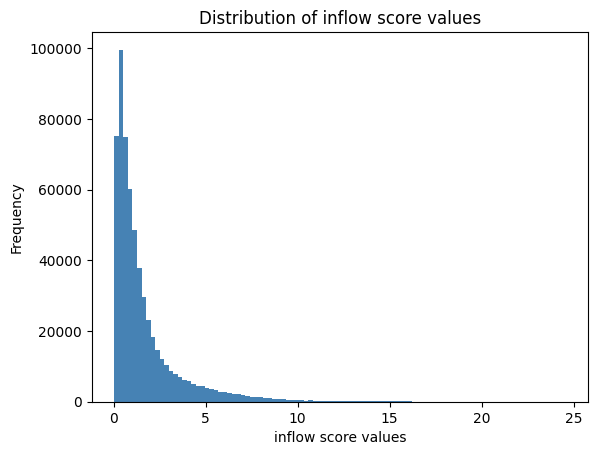

In [28]:
import scipy.sparse as sp

X = lrdata.X 
values = X.data


plt.hist(values, bins=100, color='steelblue')
plt.xlabel("inflow score values")
plt.ylabel("Frequency")
plt.title("Distribution of inflow score values")
plt.show()

In [30]:
sc.pp.log1p(lrdata)

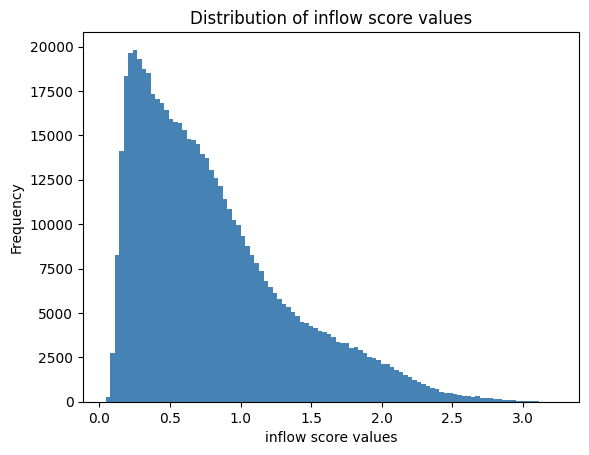

In [31]:

X = lrdata.X 
values = X.data


plt.hist(values, bins=100, color='steelblue')
plt.xlabel("inflow score values")
plt.ylabel("Frequency")
plt.title("Distribution of inflow score values")
plt.show()

## Find Global scores

In [32]:
li.mt.compute_global_score(lrdata, groupby='cell_type')

In [33]:
lrdata.uns["global_score"].sort_values('lr_mean').tail(20)

,ligand,ligand_complex,receptor,receptor_complex,source,target,lr_mean
4353,Fgf1,Fgf1,Egfr,Egfr,oligodendrocyte,astrocyte,0.569712
21764,Efna5,Efna5,Ephb1,Ephb1,GABAergic neuron,glycinergic neuron,0.570637
21775,Penk,Penk,Oprm1,Oprm1,GABAergic neuron,glycinergic neuron,0.576084
21769,Fgf13,Fgf13,Scn5a,Scn5a,GABAergic neuron,glycinergic neuron,0.576935
4464,Fgf13,Fgf13,Egfr,Egfr,glutamatergic neuron,astrocyte,0.594489
13307,Efna5,Efna5,Epha6,Epha6,GABAergic neuron,GABAergic neuron,0.607101
12137,Efna5,Efna5,Epha6,Epha6,glutamatergic neuron,monocyte,0.638895
16932,Efna5,Efna5,Ephb1,Ephb1,GABAergic neuron,dopaminergic neuron,0.639349
11738,Vcan,Vcan,Itga4,Itga4,oligodendrocyte precursor cell,lymphocyte,0.647090
15761,Efna5,Efna5,Epha6,Epha6,glutamatergic neuron,glutamatergic neuron,0.662896


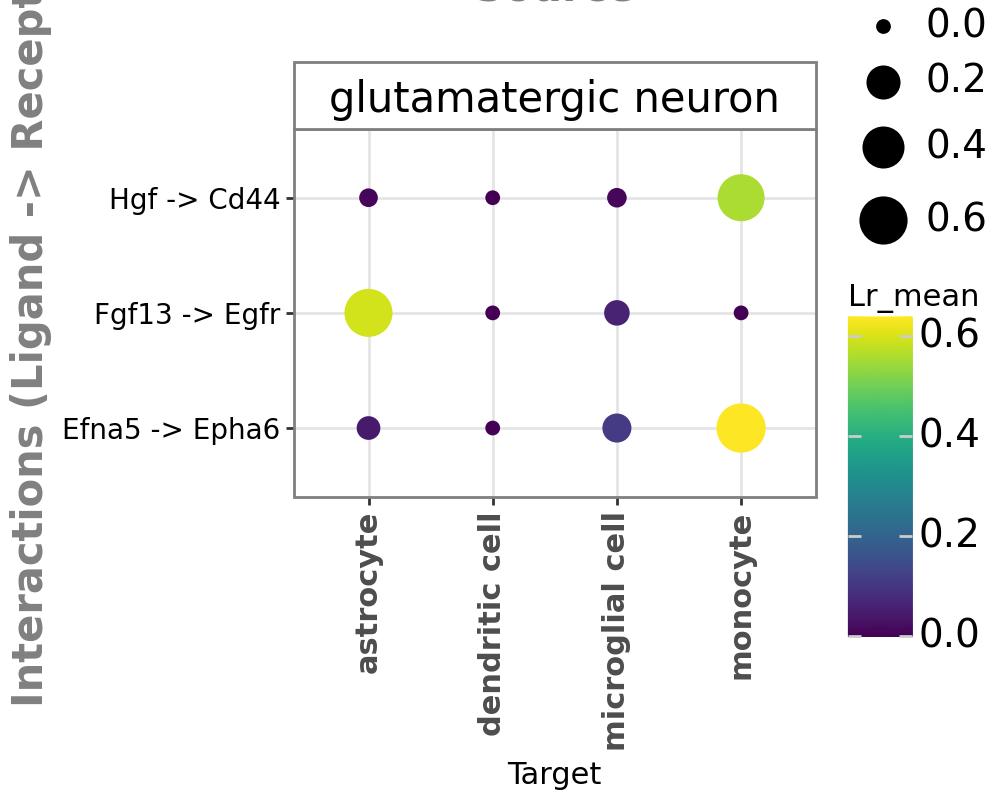

In [34]:
li.pl.dotplot(adata = lrdata, 
              colour='lr_mean',
              size = "lr_mean",
              source_labels=['glutamatergic neuron'],
              target_labels=[ "monocyte", "microglial cell", "dendritic cell", "astrocyte"],
              filter_fun=lambda x: x['lr_mean'] > 0.5,
              figure_size=(5, 4),
              uns_key='global_score' 
             )

## Visualize interaction

In [35]:
lrdata.layers['transformed'] = li.utils.zi_minmax(lrdata.X, cutoff=0.01)

In [36]:
lrdata.var_names

Index(['GABAergic neuron^Vegfc^Vipr2', 'glutamatergic neuron^Ntf3^Ntrk3',
       'glutamatergic neuron^Efna5^Epha4', 'GABAergic neuron^Gnb3^Gabbr2',
       'choroid plexus epithelial cell^Col18a1^Gpc4',
       'neuroblast (sensu Vertebrata)^Ntf3^Ntrk3',
       'glutamatergic neuron^Efna5^Epha10', 'lymphocyte^Efna5^Epha10',
       'glutamatergic neuron^Gnb3^Gabbr2', 'GABAergic neuron^Efna5^Epha10',
       ...
       'ependymal cell^Vcan^Itga4',
       'neuroblast (sensu Vertebrata)^Pnoc^Adra2a', 'lymphocyte^Ccn2^Egfr',
       'dendritic cell^Fn1^Cd44', 'oligodendrocyte^Col14a1^Cd44',
       'ependymal cell^Pdyn^Oprd1', 'oligodendrocyte^Grp^Grpr',
       'endothelial cell^Wnt5a^Ror1', 'microglial cell^Col14a1^Cd44',
       'vascular leptomeningeal cell^Col6a3^Cd44'],
      dtype='object', length=1208)

In [70]:
interaction = "GABAergic neuron^Efna5^Epha10"
parts = interaction.split("^")
cell_type_col = "cell_type"
comp = interaction.split("^")
spatial_key = "X_spatial_coords"

In [71]:
gene_expr = lrdata2[:, interaction].X

In [72]:
# If X is sparse, convert to dense
if hasattr(gene_expr, "toarray"):
    gene_expr = gene_expr.toarray()

# Count how many cells have expression > 0
n_expressing = np.sum(gene_expr > 0)

print(f"{interaction} is expressed in {n_expressing} cells.")

GABAergic neuron^Efna5^Epha10 is expressed in 3377 cells.


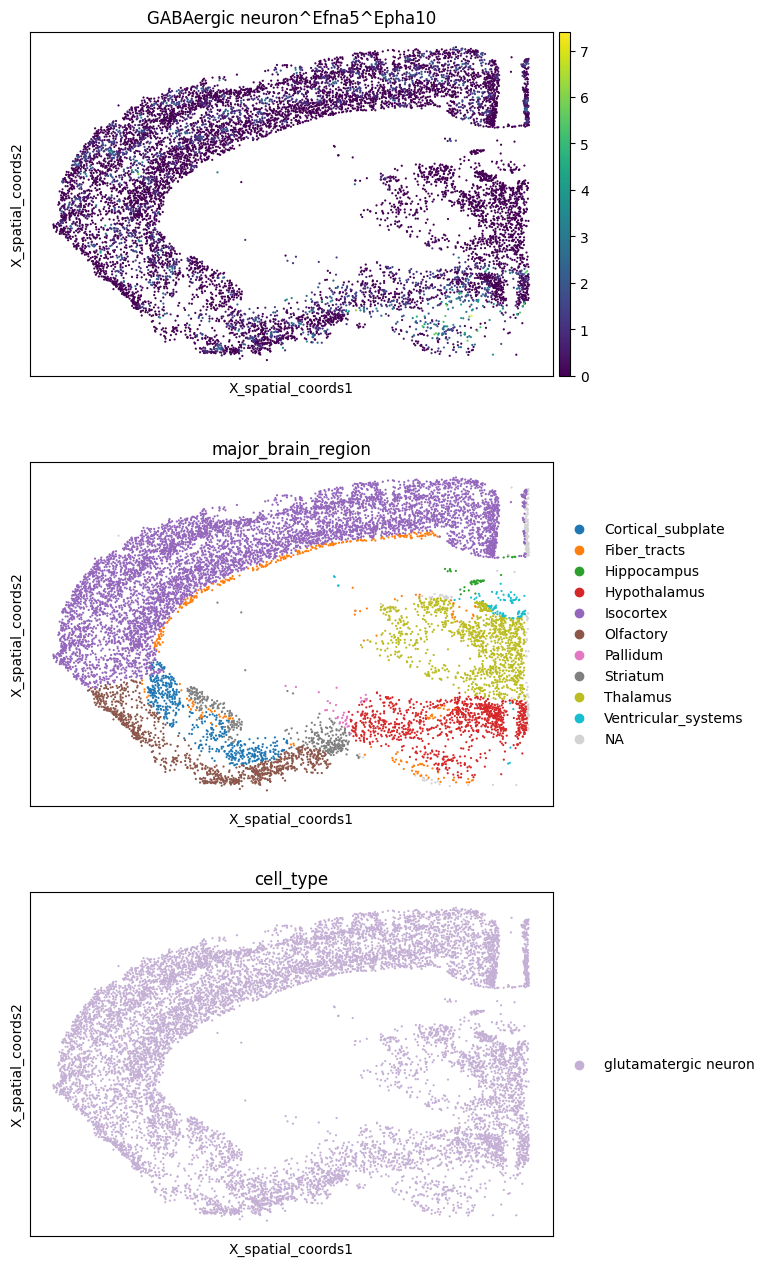

In [73]:
sc.pl.embedding(
    lrdata2,
    basis=spatial_key,
    color=[interaction, "major_brain_region", "cell_type" ],
    s=10,
    ncols=1
)

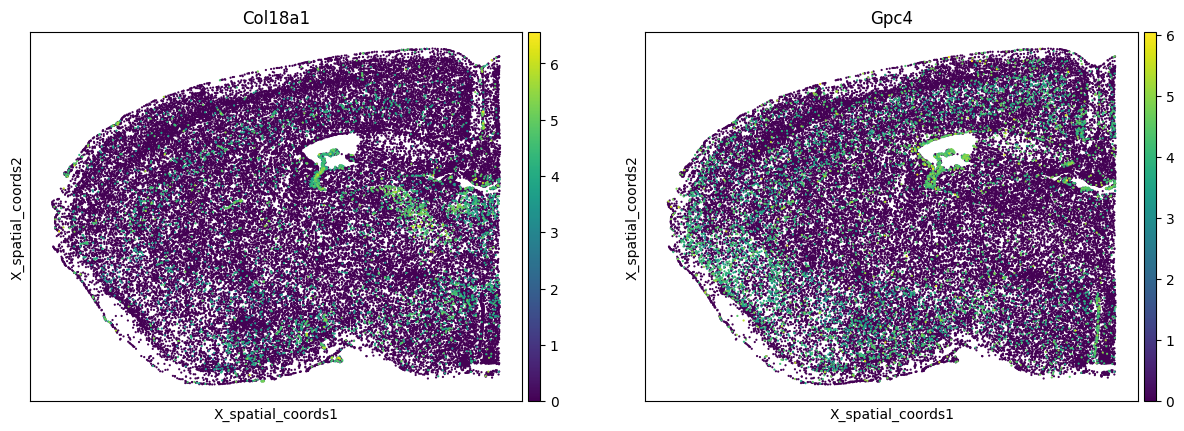

In [68]:
sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=[parts[1], parts[2]],
    s=10,
    use_raw=False
)

### Reciver cell types per region

In [43]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# --- helpers
def _as_list(x):
    if isinstance(x, (list, tuple, np.ndarray, pd.Index)):
        return list(x)
    return [x]

def global_y_lims(adata, keys):
    """
    Compute global y-limits for each key across the WHOLE dataset,
    so all regions share the same scales per panel.
    Works whether keys are var_names (genes) or .obs columns.
    """
    keys = _as_list(keys)
    ymins, ymaxs = [], []
    for k in keys:
        if k in adata.obs.columns:
            vals = adata.obs[k].to_numpy()
        else:
            vals = adata.to_df()[k].to_numpy()  # gene in var_names
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            ymins.append(0.0); ymaxs.append(1.0)
        else:
            ymins.append(np.nanmin(vals))
            ymaxs.append(np.nanmax(vals))
    return list(zip(ymins, ymaxs))  # [(ymin,ymax) per key]

def add_n_to_xticklabels(ax, counts_by_group):
    """
    Add '(n=..)' to x tick labels for a single axis.
    counts_by_group: dict {group: n}
    """
    ticks = ax.get_xticks()
    labels = [tick.get_text() for tick in ax.get_xticklabels()]
    # Matplotlib sometimes empties labels until draw; fall back to category order in counts
    if not any(labels):
        labels = list(counts_by_group.keys())
    new_labels = []
    for lab in labels:
        g = lab
        n = counts_by_group.get(g, 0)
        new_labels.append(f"{lab}\n(n={n})")
    ax.set_xticks(ticks)
    ax.set_xticklabels(new_labels, rotation=90, ha="center")

def cliffs_delta(x, y):
    """
    Cliff's delta: delta = ( (#x>y - #x<y) ) / (len(x)*len(y)).
    Returns delta in [-1, 1] and a magnitude label (per Romano et al. common cutoffs).
    """
    x = np.asarray(x); y = np.asarray(y)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return np.nan, "NA"
    # Efficient pairwise compare via sorting
    x_sorted = np.sort(x)
    y_sorted = np.sort(y)

    # Count # of y less than each x and # greater than each x using searchsorted
    import bisect
    greater = 0
    less = 0
    for xi in x_sorted:
        less += np.searchsorted(y_sorted, xi, side="left")
        greater += ny - np.searchsorted(y_sorted, xi, side="right")
    delta = (greater - less) / (nx * ny)

    # magnitude bins (you can tweak cutoffs if you prefer Vargha–Delaney A)
    ad = abs(delta)
    if ad < 0.147: mag = "negligible"
    elif ad < 0.33: mag = "small"
    elif ad < 0.474: mag = "medium"
    else: mag = "large"
    return float(delta), mag

def summarize_by_region_celltype(adata, keys, region_col, cell_type_col, threshold=0.05):
    """
    For each key (feature), region, and cell type: median, 90th pct, % > threshold, counts.
    Adds ranks within-region and across-regions (by median).
    Returns a tidy DataFrame.
    """
    keys = _as_list(keys)
    frames = []
    # choose source for keys
    df_all = adata.to_df()  # genes
    obs = adata.obs

    for k in keys:
        if k in obs.columns:
            vals = obs[k]
        else:
            vals = df_all[k]

        tmp = pd.DataFrame({
            region_col: obs[region_col].values,
            cell_type_col: obs[cell_type_col].values,
            k: vals.values
        }).dropna(subset=[region_col, cell_type_col, k])

        g = tmp.groupby([region_col, cell_type_col], observed=True)[k]
        out = g.agg(
            n="size",
            median="median",
            p90=lambda s: np.percentile(s, 90),
            pct_gt=lambda s: (np.asarray(s) > threshold).mean() * 100.0
        ).reset_index()
        out["key"] = k

        # ranks by median (1 = highest)
        out["rank_within_region_by_median"] = out.groupby(region_col, observed=True)["median"].rank(ascending=False, method="min")
        # across regions: rank cell types globally per key, still useful for quick scan
        out["rank_across_regions_by_median"] = out.groupby(["key"], observed=True)["median"].rank(ascending=False, method="min")

        frames.append(out)

    res = pd.concat(frames, ignore_index=True)
    # Sort for readability
    res = res.sort_values(["key", region_col, "median"], ascending=[True, True, False], kind="stable")
    return res.rename(columns={"p90": "p90", "pct_gt": f"pct_gt_{threshold}"})

def effect_sizes_vs_rest(adata, keys, region_col, cell_type_col):
    """
    For each region & key & cell type: Cliff's delta of (cell type) vs (all other cell types in same region).
    Also computes Mann–Whitney U p-value and BH-FDR per (region,key) family.
    Returns a tidy DataFrame with delta, magnitude, U, p, q (FDR).
    """
    keys = _as_list(keys)
    df_all = adata.to_df()
    obs = adata.obs

    rows = []
    for region in obs[region_col].dropna().unique():
        region_mask = (obs[region_col] == region)
        ct_series = obs.loc[region_mask, cell_type_col]
        cts = ct_series.dropna().unique()
        for k in keys:
            if k in obs.columns:
                vals = obs.loc[region_mask, k].to_numpy()
            else:
                vals = df_all.loc[region_mask, k].to_numpy()
            ct_vec = ct_series.to_numpy()

            # compute for each cell type in this region
            for ct in cts:
                in_mask = (ct_vec == ct)
                x = vals[in_mask]
                y = vals[~in_mask]

                # Cliff's delta
                delta, mag = cliffs_delta(x, y)

                # Mann-Whitney U (two-sided) for p-value
                if np.isfinite(delta) and x.size > 0 and y.size > 0:
                    try:
                        U, p = mannwhitneyu(x, y, alternative="two-sided")
                    except ValueError:
                        U, p = np.nan, np.nan
                else:
                    U, p = np.nan, np.nan

                rows.append({
                    "region": region,
                    "key": k,
                    "cell_type": ct,
                    "n_in": int(x.size),
                    "n_out": int(y.size),
                    "cliffs_delta": delta,
                    "magnitude": mag,
                    "mwU": U,
                    "pval": p,
                })

    ef = pd.DataFrame(rows)

    # BH-FDR within each (region, key) family of tests
    def _fdr(group):
        p = group["pval"].to_numpy()
        # handle all-nan case
        if np.all(~np.isfinite(p)):
            group["qval"] = np.nan
        else:
            p_clean = np.where(np.isfinite(p), p, 1.0)
            _, q, _, _ = multipletests(p_clean, method="fdr_bh")
            # restore NaNs to q where p was NaN
            q = np.where(np.isfinite(p), q, np.nan)
            group["qval"] = q
        return group

    ef = ef.groupby(["region", "key"], group_keys=False).apply(_fdr)
    ef["significant_fdr_5pct"] = ef["qval"] < 0.05
    ef = ef.sort_values(["key", "region", "qval", "cliffs_delta"], ascending=[True, True, True, False], kind="stable")
    return ef

In [44]:
def plot_region_violins_with_fixed_ylim(
    adata, keys, region_col, cell_type_col,
    title_prefix="Region", add_counts=True,
    expr_threshold=0.05, prop_digits=2
):
    """
    Plots violins per region with identical y-limits per key.
    Tick labels show per-cell-type counts AND proportion expressing (> expr_threshold):
        'CellType (n=500, p=0.50)'
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import scanpy as sc

    def _as_list(x):
        if isinstance(x, (list, tuple, np.ndarray, pd.Index)):
            return list(x)
        return [x]

    def global_y_lims(adata, keys):
        keys = _as_list(keys)
        ymins, ymaxs = [], []
        df_all = adata.to_df()
        for k in keys:
            if k in adata.obs.columns:
                vals = adata.obs[k].to_numpy()
            else:
                vals = df_all[k].to_numpy()
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                ymins.append(0.0); ymaxs.append(1.0)
            else:
                ymins.append(np.nanmin(vals))
                ymaxs.append(np.nanmax(vals))
        return list(zip(ymins, ymaxs))

    def add_label_n_and_p(ax, labels_order, n_exp, p_prop):
        # labels_order is a list of group names in the axis order
        new_labels = []
        for g in labels_order:
            ne = int(n_exp.get(g, 0))
            pp = float(p_prop.get(g, 0.0))
            new_labels.append(f"{g}\n(n={ne}, p={pp:.{prop_digits}f})")
        ax.set_xticklabels(new_labels, rotation=90, ha="center")

    def get_values(adata, key):
        # helper to fetch a vector for 'key' from X (genes) or obs
        if key in adata.obs.columns:
            return adata.obs[key].to_numpy()
        return adata.to_df()[key].to_numpy()

    keys_list = _as_list(keys)
    ylims = global_y_lims(adata, keys_list)

    for region in adata.obs[region_col].dropna().unique():
        ad = adata[adata.obs[region_col] == region]
        # filter out small cell types (<5% of region total)
        region_total = ad.n_obs
        counts = ad.obs[cell_type_col].value_counts()
        keep_ct = counts[counts >= 0.05 * region_total].index
        ad = ad[ad.obs[cell_type_col].isin(keep_ct)]


        ax = sc.pl.violin(
            ad,
            keys=keys_list,
            groupby=cell_type_col,
            use_raw=False,
            show=False,
            stripplot=False,
            scale="width",
        )

        axes = ax if isinstance(ax, (list, np.ndarray)) else [ax]
        axes = np.array(axes).ravel().tolist()

        # Precompute totals per group in this region (denominator for p)
        totals_by_group = ad.obs.groupby(cell_type_col, observed=True).size()

        # For each axis (key), compute expressing counts and proportions, then label
        for i, axi in enumerate(axes):
            # y-lims (consistent across regions for this key)
            if i < len(ylims):
                lo, hi = ylims[i]
                span = hi - lo
                axi.set_ylim(lo - 0.02 * span, hi + 0.02 * span)

            if add_counts:
                k = keys_list[i] if i < len(keys_list) else keys_list[-1]
                vals_k = get_values(ad, k)

                # Boolean expressing mask per cell (value > threshold)
                expr_mask = np.isfinite(vals_k) & (vals_k > expr_threshold)

                # Build a per-cell DataFrame (group & expr flag) for aggregation
                g_series = ad.obs[cell_type_col].astype(str)
                # counts expressing per group
                n_exp = g_series[expr_mask].value_counts()
                # ensure all groups present
                n_exp = n_exp.reindex(totals_by_group.index.astype(str), fill_value=0)

                # proportions per group
                p_prop = (n_exp / totals_by_group.astype(float)).replace([np.inf, -np.inf], np.nan).fillna(0.0)

                # Determine axis order of groups
                tick_texts = [t.get_text() for t in axi.get_xticklabels()]
                if any(tick_texts):
                    labels_order = [t.split("\n")[0] for t in tick_texts]  # strip previous decorations
                else:
                    labels_order = list(totals_by_group.index.astype(str))

                add_label_n_and_p(axi, labels_order, n_exp.to_dict(), p_prop.to_dict())

        plt.gcf().suptitle(f"{title_prefix}: {region}", y=0.98)
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()


In [ ]:
lrdata.obs["major_brain_region"].value_counts()

In [ ]:
plot_region_violins_with_fixed_ylim(
    lrdata,
    keys=interaction,                
    region_col="major_brain_region",
    cell_type_col=cell_type_col,
    title_prefix="Region",
    add_counts=True,
    expr_threshold=0.05,              
    prop_digits=2                     
)

### Plot sender^L^R^reciver cell type

In [ ]:
lrdata.obs["cell_type"].value_counts()

In [ ]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=interaction,
    s=10,
    use_raw=False
)

In [159]:
# Define the subset condition
highlight = (
    (lrdata.obs["major_brain_region"] == "Hypothalamus")
)

# Create a new column for plotting
lrdata.obs["highlight_group"] = "Other cells"
lrdata.obs.loc[highlight, "highlight_group"] = "Hypothalamus"


In [ ]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color="highlight_group",
    palette=["#E64B35", "lightgrey"],  # grey for background, red for highlight
    s=10,
    use_raw=False
)


In [161]:
hippothalamus_lrdata = lrdata[lrdata.obs["major_brain_region"] == "Hypothalamus"]

In [ ]:
hippothalamus_lrdata.obs["cell_type"].value_counts()

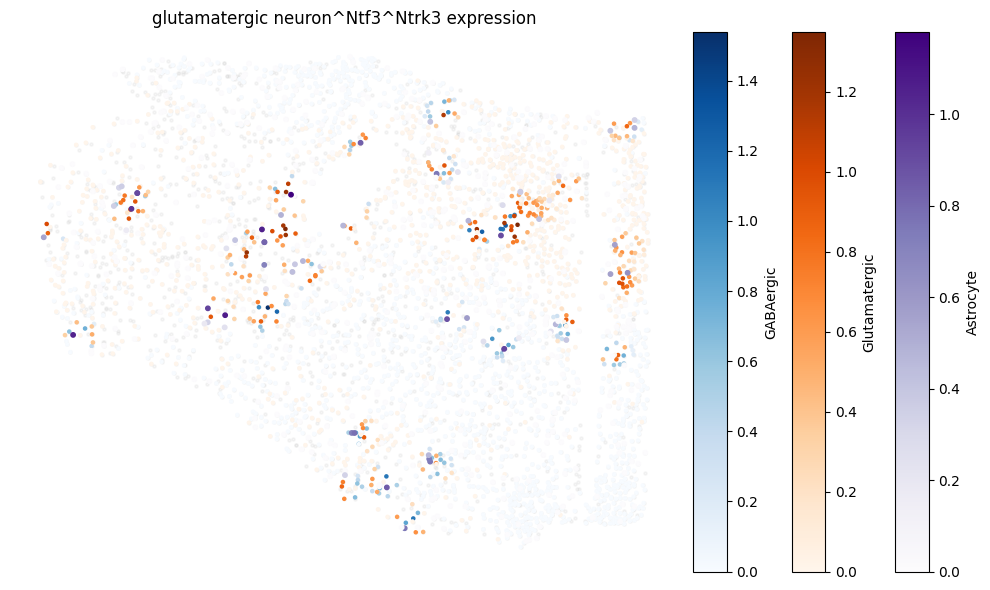

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable



hippothalamus_lrdata = lrdata[lrdata.obs["major_brain_region"] == "Hypothalamus"]



# Extract spatial coordinates
coords = hippothalamus_lrdata.obsm[spatial_key]

# Define masks
type1_mask = hippothalamus_lrdata.obs["cell_type"].eq("GABAergic neuron")
type2_mask = hippothalamus_lrdata.obs["cell_type"].eq("glutamatergic neuron")
type3_mask = hippothalamus_lrdata.obs["cell_type"].eq("astrocyte")

# Coordinates per type
coords_type1 = coords[type1_mask.values, :]
coords_type2 = coords[type2_mask.values, :]
coords_type3 = coords[type3_mask.values, :] 


# Get expression values for the gene (from .X or .raw depending on your setup)
gene_name = interaction 
adata = hippothalamus_lrdata

# Check whether to use .raw
adata = hippothalamus_lrdata
if adata.raw is not None and gene_name in adata.raw.var_names:
    expr_type1 = adata.raw[type1_mask][:, gene_name].X
    expr_type2 = adata.raw[type2_mask][:, gene_name].X
    expr_type3 = adata.raw[type3_mask][:, gene_name].X
else:
    expr_type1 = adata[type1_mask][:, gene_name].X
    expr_type2 = adata[type2_mask][:, gene_name].X
    expr_type3 = adata[type3_mask][:, gene_name].X

# Convert sparse matrix to 1D arrays if needed
expr_type1 = expr_type1.toarray().ravel() if not isinstance(expr_type1, np.ndarray) else expr_type1
expr_type2 = expr_type2.toarray().ravel() if not isinstance(expr_type2, np.ndarray) else expr_type2
expr_type3 = expr_type3.toarray().ravel() if not isinstance(expr_type3, np.ndarray) else expr_type3


from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10, 6))

# Plot background
ax.scatter(coords[:, 0], coords[:, 1], color='lightgrey', s=5, alpha=0.2)

# Scatter plots
sc1 = ax.scatter(coords_type1[:, 0], coords_type1[:, 1], c=expr_type1, cmap='Blues', s=5)
sc2 = ax.scatter(coords_type2[:, 0], coords_type2[:, 1], c=expr_type2, cmap='Oranges', s=5)
sc3 = ax.scatter(coords_type3[:, 0], coords_type3[:, 1], c=expr_type3, cmap='Purples', s=10) 

# Astrocytes in fixed black color
#ax.scatter([:, 0], [:, 1], color='black', s=3, alpha=0.4, label='glutamatergic neuro')

# Set up divider to place colorbars side-by-side
divider = make_axes_locatable(ax)
cax1 = divider.append_axes("right", size="5%", pad=0.15)
cax2 = divider.append_axes("right", size="5%", pad=0.65)
cax3 = divider.append_axes("right", size="5%", pad=0.7)

# Colorbars
cb1 = plt.colorbar(sc1, cax=cax1)
cb1.set_label("GABAergic")

cb2 = plt.colorbar(sc2, cax=cax2)
cb2.set_label("Glutamatergic")

cb3 = plt.colorbar(sc3, cax=cax3)
cb3.set_label("Astrocyte")

# Final formatting
ax.set_title(f"{interaction} expression")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Evaluation of Inflow Score Predictive Power Using Random Forest Classification

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [79]:
# 1) build boolean mask as NumPy array
mask = lrdata.obs["tissue"].notna().to_numpy()

# 2) subset the AnnData (preserves row order)
lrdata_filt = lrdata[mask].copy()

# 3) pull aligned X and y
X_filtered = lrdata_filt.X
y_filtered = lrdata_filt.obs["tissue"]  


In [80]:
# Check if the indices are identical
print((lrdata_filt.obs_names == y_filtered.index).all())

True


In [81]:
# Encode categorical tissue labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered)

In [83]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [84]:
clf.fit(X_train, y_train)

/home/alsayah/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [85]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6461408291811601

Classification Report:
                              precision    recall  f1-score   support

                      brain       0.47      0.50      0.49       958
          cortical subplate       0.35      0.60      0.44       444
      hippocampal formation       0.24      0.62      0.34       120
               hypothalamus       0.67      0.62      0.64      1256
                  neocortex       0.90      0.72      0.80      3710
                   pallidum       0.32      0.57      0.41       272
                   striatum       0.84      0.66      0.74      1757
           thalamic complex       0.57      0.63      0.60      1167
ventricular system of brain       0.58      0.85      0.69       299
               white matter       0.35      0.43      0.39       654

                   accuracy                           0.65     10637
                  macro avg       0.53      0.62      0.55     10637
               weighted avg       0.70      0.6

In [86]:
from sklearn.metrics import roc_auc_score, roc_curve

In [87]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.9197
Multiclass ROC AUC (OvR, weighted): 0.9250


In [88]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
print("Accuracy:", rf.score(X_test, y_test))

Accuracy: 0.7221020964557676


In [89]:
# Evaluate
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7221020964557676

Classification Report:
                              precision    recall  f1-score   support

                      brain       0.69      0.44      0.54       958
          cortical subplate       0.84      0.13      0.23       444
      hippocampal formation       0.83      0.25      0.38       120
               hypothalamus       0.69      0.62      0.65      1256
                  neocortex       0.73      0.95      0.82      3710
                   pallidum       0.72      0.35      0.47       272
                   striatum       0.77      0.82      0.80      1757
           thalamic complex       0.73      0.68      0.70      1167
ventricular system of brain       0.81      0.77      0.79       299
               white matter       0.56      0.45      0.50       654

                   accuracy                           0.72     10637
                  macro avg       0.74      0.55      0.59     10637
               weighted avg       0.72      0.7

In [90]:
# Extract feature importances
importances = rf.feature_importances_

# Match to gene names
gene_names = lrdata.var_names if hasattr(lrdata, "var_names") else np.arange(X_train.shape[1])

# Sort and show top genes
top_idx = np.argsort(importances)[::-1][:20]
top_genes = pd.DataFrame({
    'Gene': gene_names[top_idx],
    'Importance': importances[top_idx]
})
print(top_genes)

                                 Gene  Importance
0    glutamatergic neuron^Efna5^Epha4    0.040743
1   glutamatergic neuron^Efna5^Epha10    0.031951
2    glutamatergic neuron^Efna5^Epha7    0.026283
3    glutamatergic neuron^Efna5^Ephb1    0.018721
4    glutamatergic neuron^Gnb3^Gabbr2    0.018284
5       GABAergic neuron^Efna5^Epha10    0.015437
6    glutamatergic neuron^Efna5^Epha6    0.014952
7        GABAergic neuron^Efna5^Epha4    0.013458
8        GABAergic neuron^Efna5^Ephb1    0.013411
9        GABAergic neuron^Efna5^Epha6    0.011949
10    glutamatergic neuron^Ntf3^Ntrk3    0.011251
11    glutamatergic neuron^Penk^Oprd1    0.011031
12        GABAergic neuron^Penk^Oprd1    0.010547
13   glutamatergic neuron^Wnt5a^Epha7    0.010125
14       GABAergic neuron^Gnb3^Gabbr2    0.010109
15         GABAergic neuron^Nts^Ntsr2    0.009630
16   glutamatergic neuron^Fgf13^Scn5a    0.008946
17       GABAergic neuron^Fgf13^Scn5a    0.008928
18        GABAergic neuron^Penk^Oprm1    0.008055


/scratch/jobs/39700990/ipykernel_1250613/3290410466.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


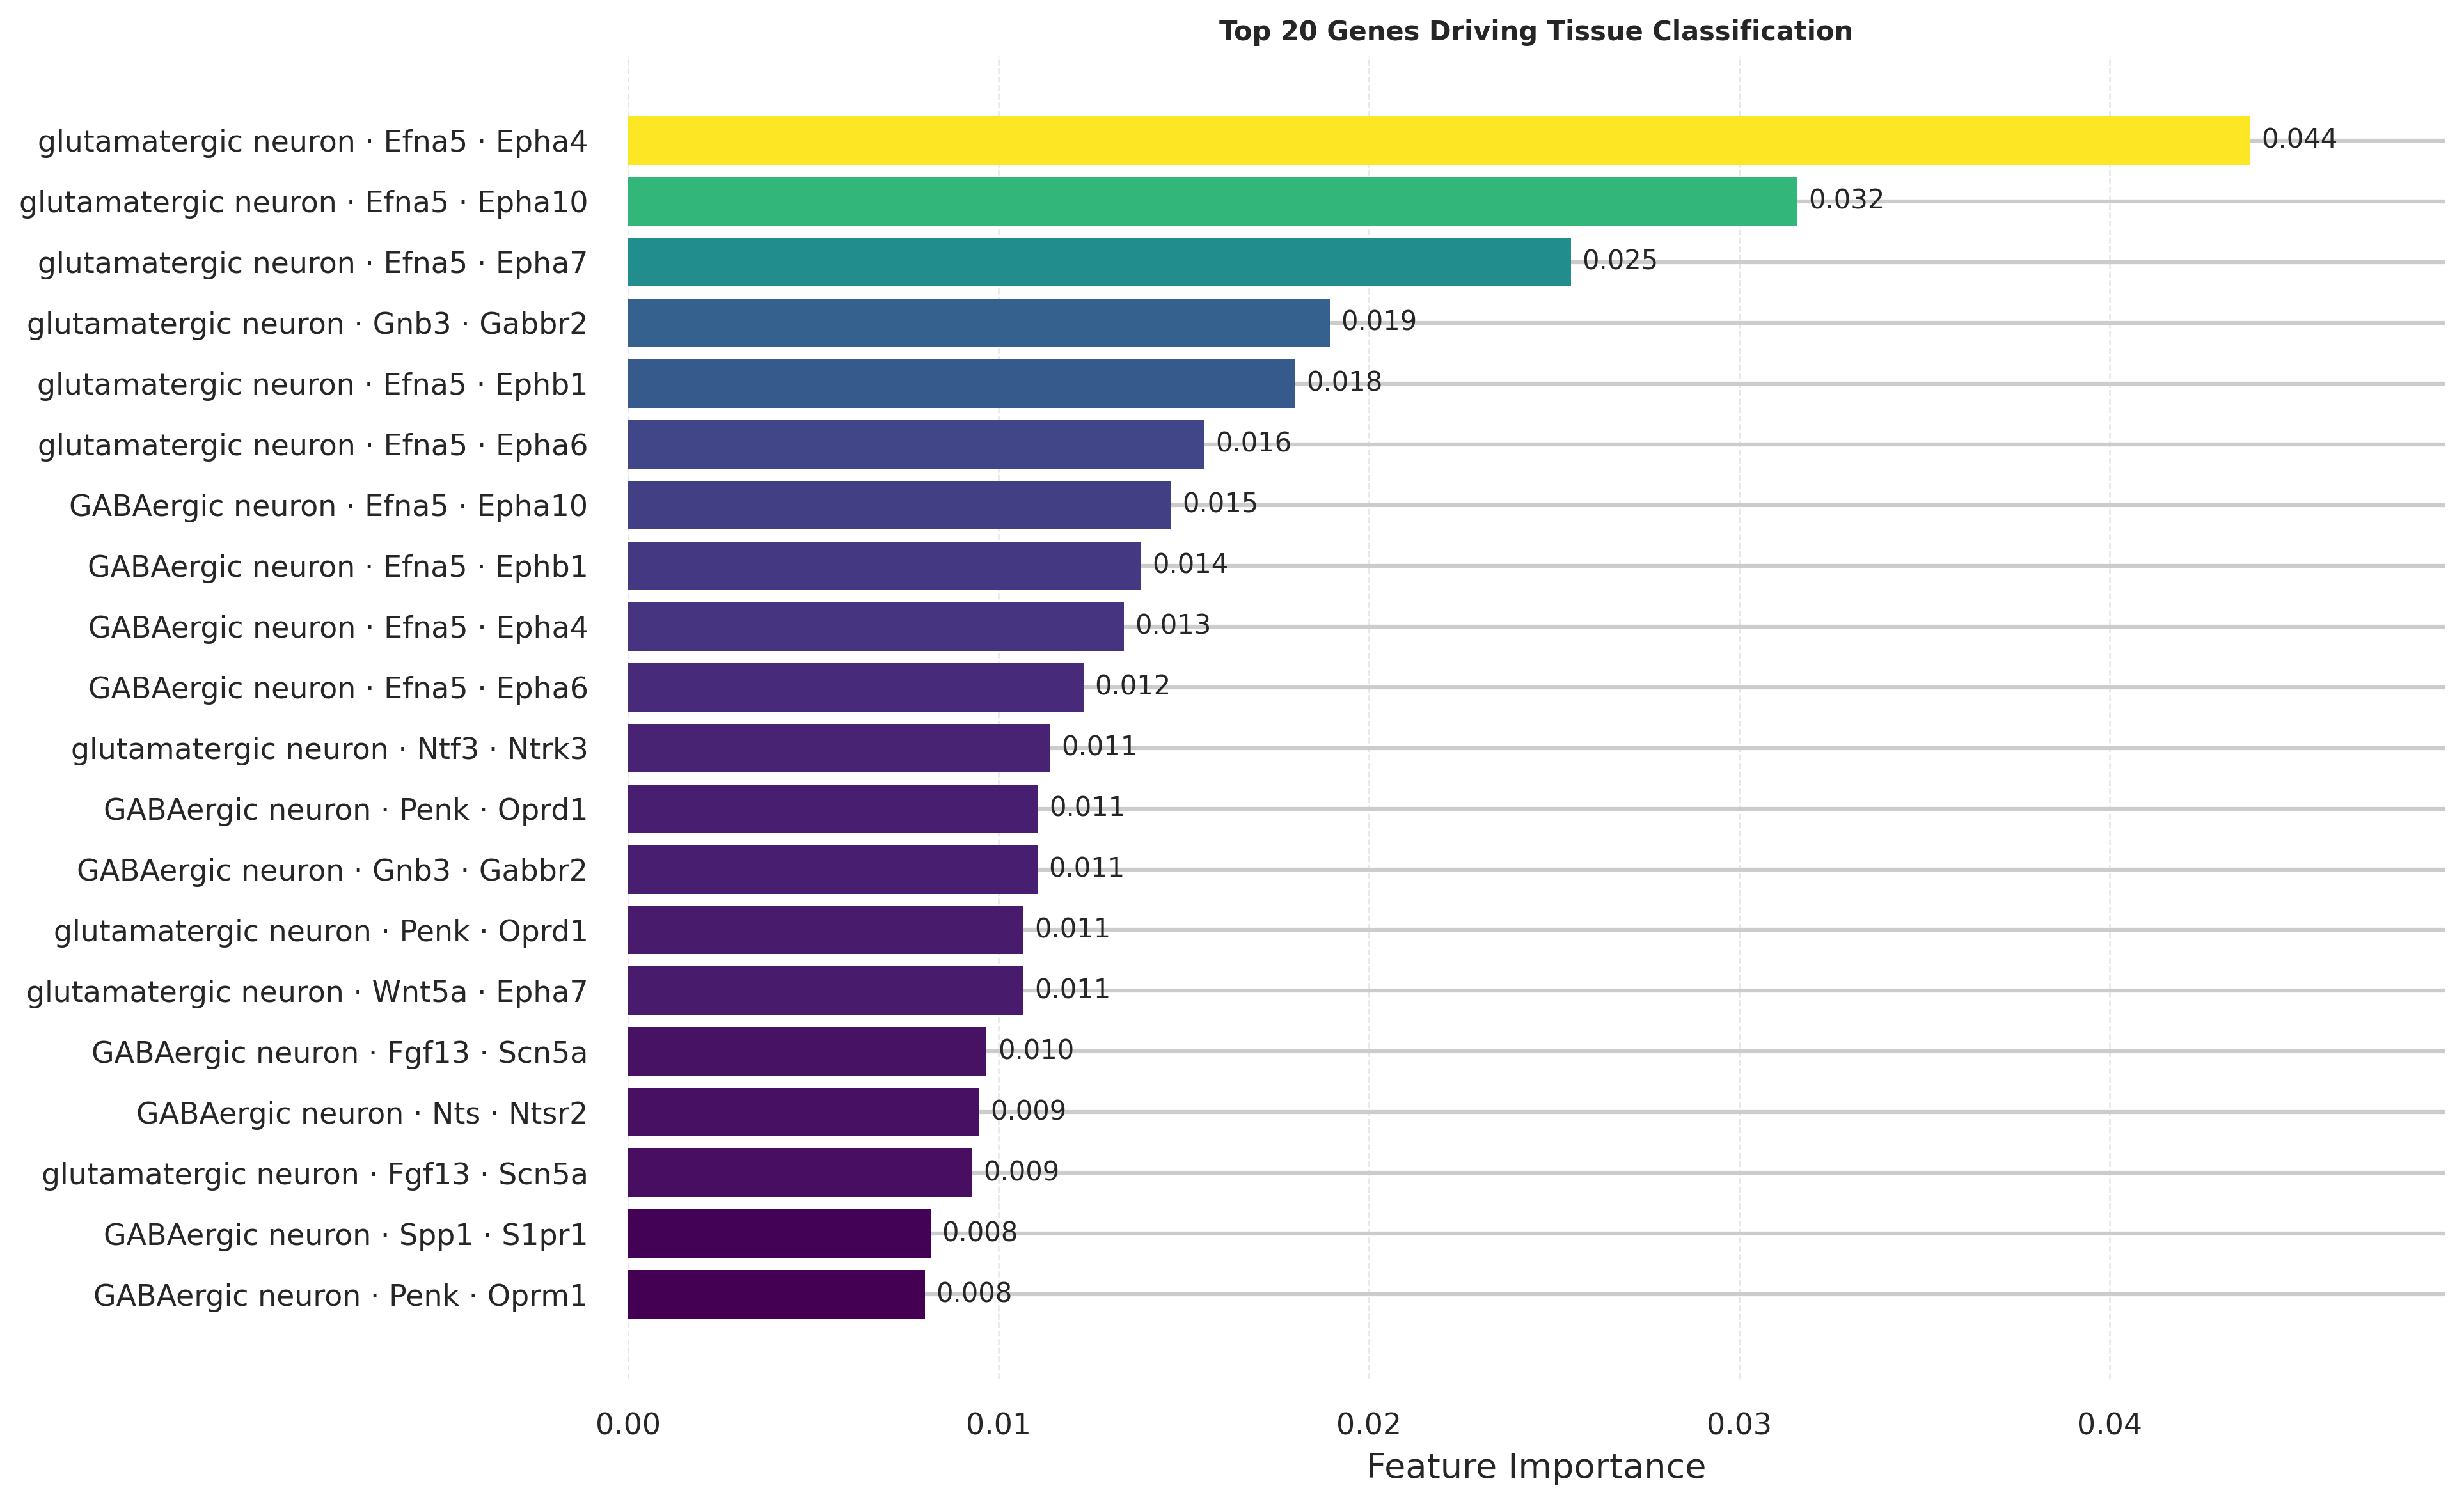

In [78]:
# Publication-quality bar chart for "top_genes" DataFrame
# Columns required: top_genes['Gene'], top_genes['Importance']

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# ---------------- Styling ----------------
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 12,
    "font.family": "DejaVu Sans",   # swap to "Arial" if available in your env
    "axes.titlesize": 10,
    "axes.labelsize": 13,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
})

# ---------------- Data prep ----------------
df = top_genes.sort_values("Importance", ascending=False).copy()
df["Label"] = df["Gene"].str.replace(r"\^", " · ", regex=True)  # nicer separators

# Reverse for barh so the largest is at the top
labels = df["Label"].iloc[::-1].to_list()
values = df["Importance"].iloc[::-1].to_numpy()

# Color scale (continuous by importance)
norm = mpl.colors.Normalize(vmin=values.min(), vmax=values.max())
cmap = mpl.cm.get_cmap("viridis")
colors = cmap(norm(values))

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(13, 8))

bars = ax.barh(labels, values, color=colors, edgecolor="none")

# Gridlines only on x for readability
ax.xaxis.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.5)
ax.set_axisbelow(True)

# Labels & title
ax.set_xlabel("Feature Importance")
ax.set_ylabel("")  # y-label not needed
ax.set_title("Top 20 Genes Driving Tissue Classification")

# Tighten x-limits with small headroom
max_val = float(values.max())
ax.set_xlim(0, max_val * 1.12)

# Annotate bars with values
for i, (b, v) in enumerate(zip(bars, values)):
    ax.text(
        v + max_val * 0.007,     # small offset to the right
        b.get_y() + b.get_height()/2,
        f"{v:.3f}",
        va="center", ha="left", fontsize=10
    )

# Reduce y tick padding so long labels fit better
ax.tick_params(axis="y", pad=6)
fig.tight_layout()

# Save high-res figure for publication
plt.savefig("top20_genes_importance.png", bbox_inches="tight")
plt.show()


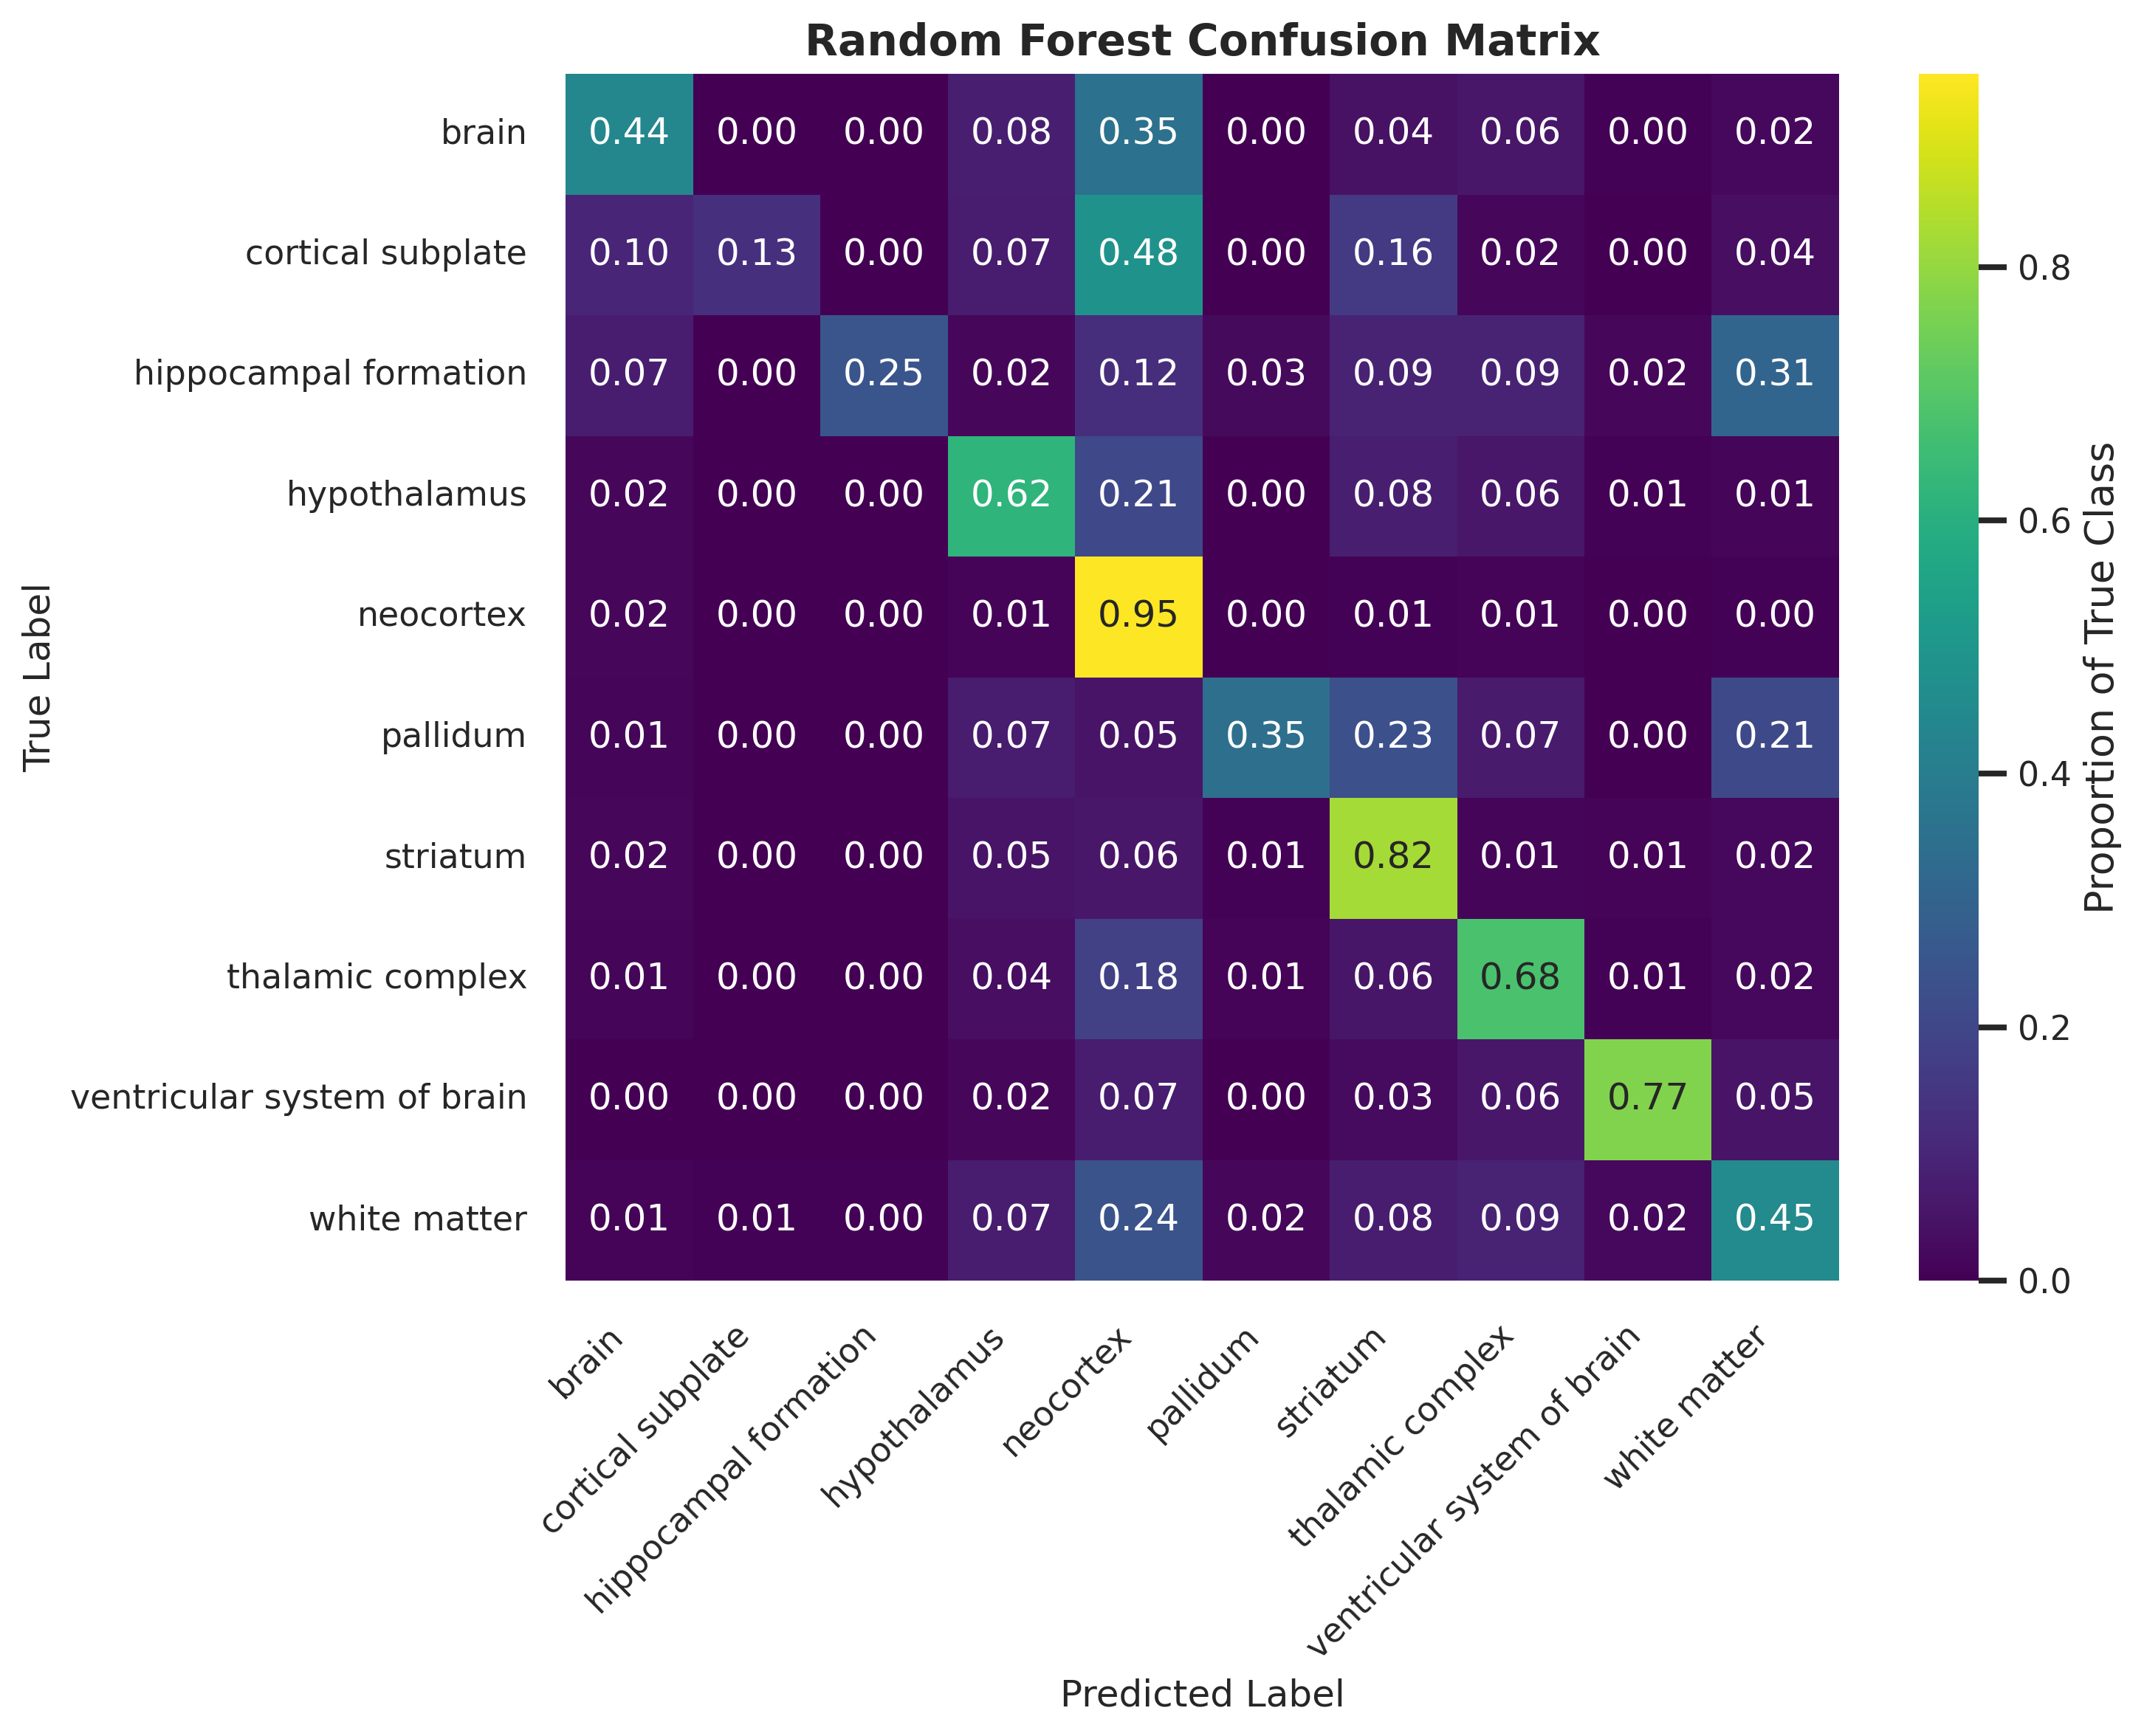

In [91]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')  # normalize for clarity
labels = np.unique(y_test)

# Set up the plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, 
            annot=True, 
            fmt=".2f", 
            cmap="viridis", 
            xticklabels=labels, 
            yticklabels=labels,
            cbar_kws={'label': 'Proportion of True Class'})

plt.title("Random Forest Confusion Matrix", fontsize=14, weight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
